In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    AdaBoostRegressor,
    BaggingRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Get the Data
train = pd.read_csv("data/Train.csv")
test = pd.read_csv("data/Test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print(train.head())
print(test.head())

Train shape: (30557, 82)
Test shape: (16136, 77)
        Place_ID X Date        Date Place_ID  target  target_min  target_max  \
0  010Q650 X 2020-01-02  2020-01-02  010Q650    38.0        23.0        53.0   
1  010Q650 X 2020-01-03  2020-01-03  010Q650    39.0        25.0        63.0   
2  010Q650 X 2020-01-04  2020-01-04  010Q650    24.0         8.0        56.0   
3  010Q650 X 2020-01-05  2020-01-05  010Q650    49.0        10.0        55.0   
4  010Q650 X 2020-01-06  2020-01-06  010Q650    21.0         9.0        52.0   

   target_variance  target_count  precipitable_water_entire_atmosphere  \
0           769.50            92                             11.000000   
1          1319.85            91                             14.600000   
2          1181.96            96                             16.400000   
3          1113.67            96                              6.911948   
4          1164.82            95                             13.900001   

   relative_humidity_2m_a

In [4]:
# First Look at the Data
train_columns = set(train.columns)
test_columns = set(test.columns)

# target is the daily PM2.5 particulate matter concentration for each city.
target_columns = train_columns - test_columns
target_name = "target"

if target_name not in target_columns:
    raise ValueError(f"'{target_name}' was not found in train-only columns: {target_columns}")


print("Target column:", target_name)


Target column: target


In [5]:
numerical_variables = train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_variables = train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical variables:")
print(numerical_variables)

print("\nCategorical variables:")
print(categorical_variables)

Numerical variables:
['target', 'target_min', 'target_max', 'target_variance', 'target_count', 'precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground', 'u_component_of_wind_10m_above_ground', 'v_component_of_wind_10m_above_ground', 'L3_NO2_NO2_column_number_density', 'L3_NO2_NO2_slant_column_number_density', 'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction', 'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle', 'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle', 'L3_NO2_solar_zenith_angle', 'L3_NO2_stratospheric_NO2_column_number_density', 'L3_NO2_tropopause_pressure', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature', 'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle', 'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle', 'L3_O3_solar_zenith_angle', 'L3_CO_CO_column_number_density', 'L3_CO_H2O_column_number_d

In [6]:
# Exclude the target, target-derived summaries, and identifier/date columns.
target_derived_columns = target_columns
columns_to_exclude = target_derived_columns | {"Place_ID X Date", "Date", "Place_ID"}
X_train1 = train.drop(columns=list(columns_to_exclude))
y_train1 = train[target_name]

print("Columns excluded from features:", columns_to_exclude)
print("X feature :", X_train1.columns.tolist())

Columns excluded from features: {'Place_ID', 'target', 'target_max', 'target_variance', 'Place_ID X Date', 'Date', 'target_count', 'target_min'}
X feature : ['precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground', 'u_component_of_wind_10m_above_ground', 'v_component_of_wind_10m_above_ground', 'L3_NO2_NO2_column_number_density', 'L3_NO2_NO2_slant_column_number_density', 'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction', 'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle', 'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle', 'L3_NO2_solar_zenith_angle', 'L3_NO2_stratospheric_NO2_column_number_density', 'L3_NO2_tropopause_pressure', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature', 'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle', 'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle', 'L3_O3_solar_zenith_angle

In [7]:
len(X_train1.columns)

74

In [8]:
X_train1.columns.tolist()

['precipitable_water_entire_atmosphere',
 'relative_humidity_2m_above_ground',
 'specific_humidity_2m_above_ground',
 'temperature_2m_above_ground',
 'u_component_of_wind_10m_above_ground',
 'v_component_of_wind_10m_above_ground',
 'L3_NO2_NO2_column_number_density',
 'L3_NO2_NO2_slant_column_number_density',
 'L3_NO2_absorbing_aerosol_index',
 'L3_NO2_cloud_fraction',
 'L3_NO2_sensor_altitude',
 'L3_NO2_sensor_azimuth_angle',
 'L3_NO2_sensor_zenith_angle',
 'L3_NO2_solar_azimuth_angle',
 'L3_NO2_solar_zenith_angle',
 'L3_NO2_stratospheric_NO2_column_number_density',
 'L3_NO2_tropopause_pressure',
 'L3_NO2_tropospheric_NO2_column_number_density',
 'L3_O3_O3_column_number_density',
 'L3_O3_O3_effective_temperature',
 'L3_O3_cloud_fraction',
 'L3_O3_sensor_azimuth_angle',
 'L3_O3_sensor_zenith_angle',
 'L3_O3_solar_azimuth_angle',
 'L3_O3_solar_zenith_angle',
 'L3_CO_CO_column_number_density',
 'L3_CO_H2O_column_number_density',
 'L3_CO_cloud_height',
 'L3_CO_sensor_altitude',
 'L3_CO_se

In [9]:
y_train1.name

'target'

In [10]:
X_train1.isnull().sum()



precipitable_water_entire_atmosphere        0
relative_humidity_2m_above_ground           0
specific_humidity_2m_above_ground           0
temperature_2m_above_ground                 0
u_component_of_wind_10m_above_ground        0
                                        ...  
L3_CH4_aerosol_optical_depth            24765
L3_CH4_sensor_azimuth_angle             24765
L3_CH4_sensor_zenith_angle              24765
L3_CH4_solar_azimuth_angle              24765
L3_CH4_solar_zenith_angle               24765
Length: 74, dtype: int64

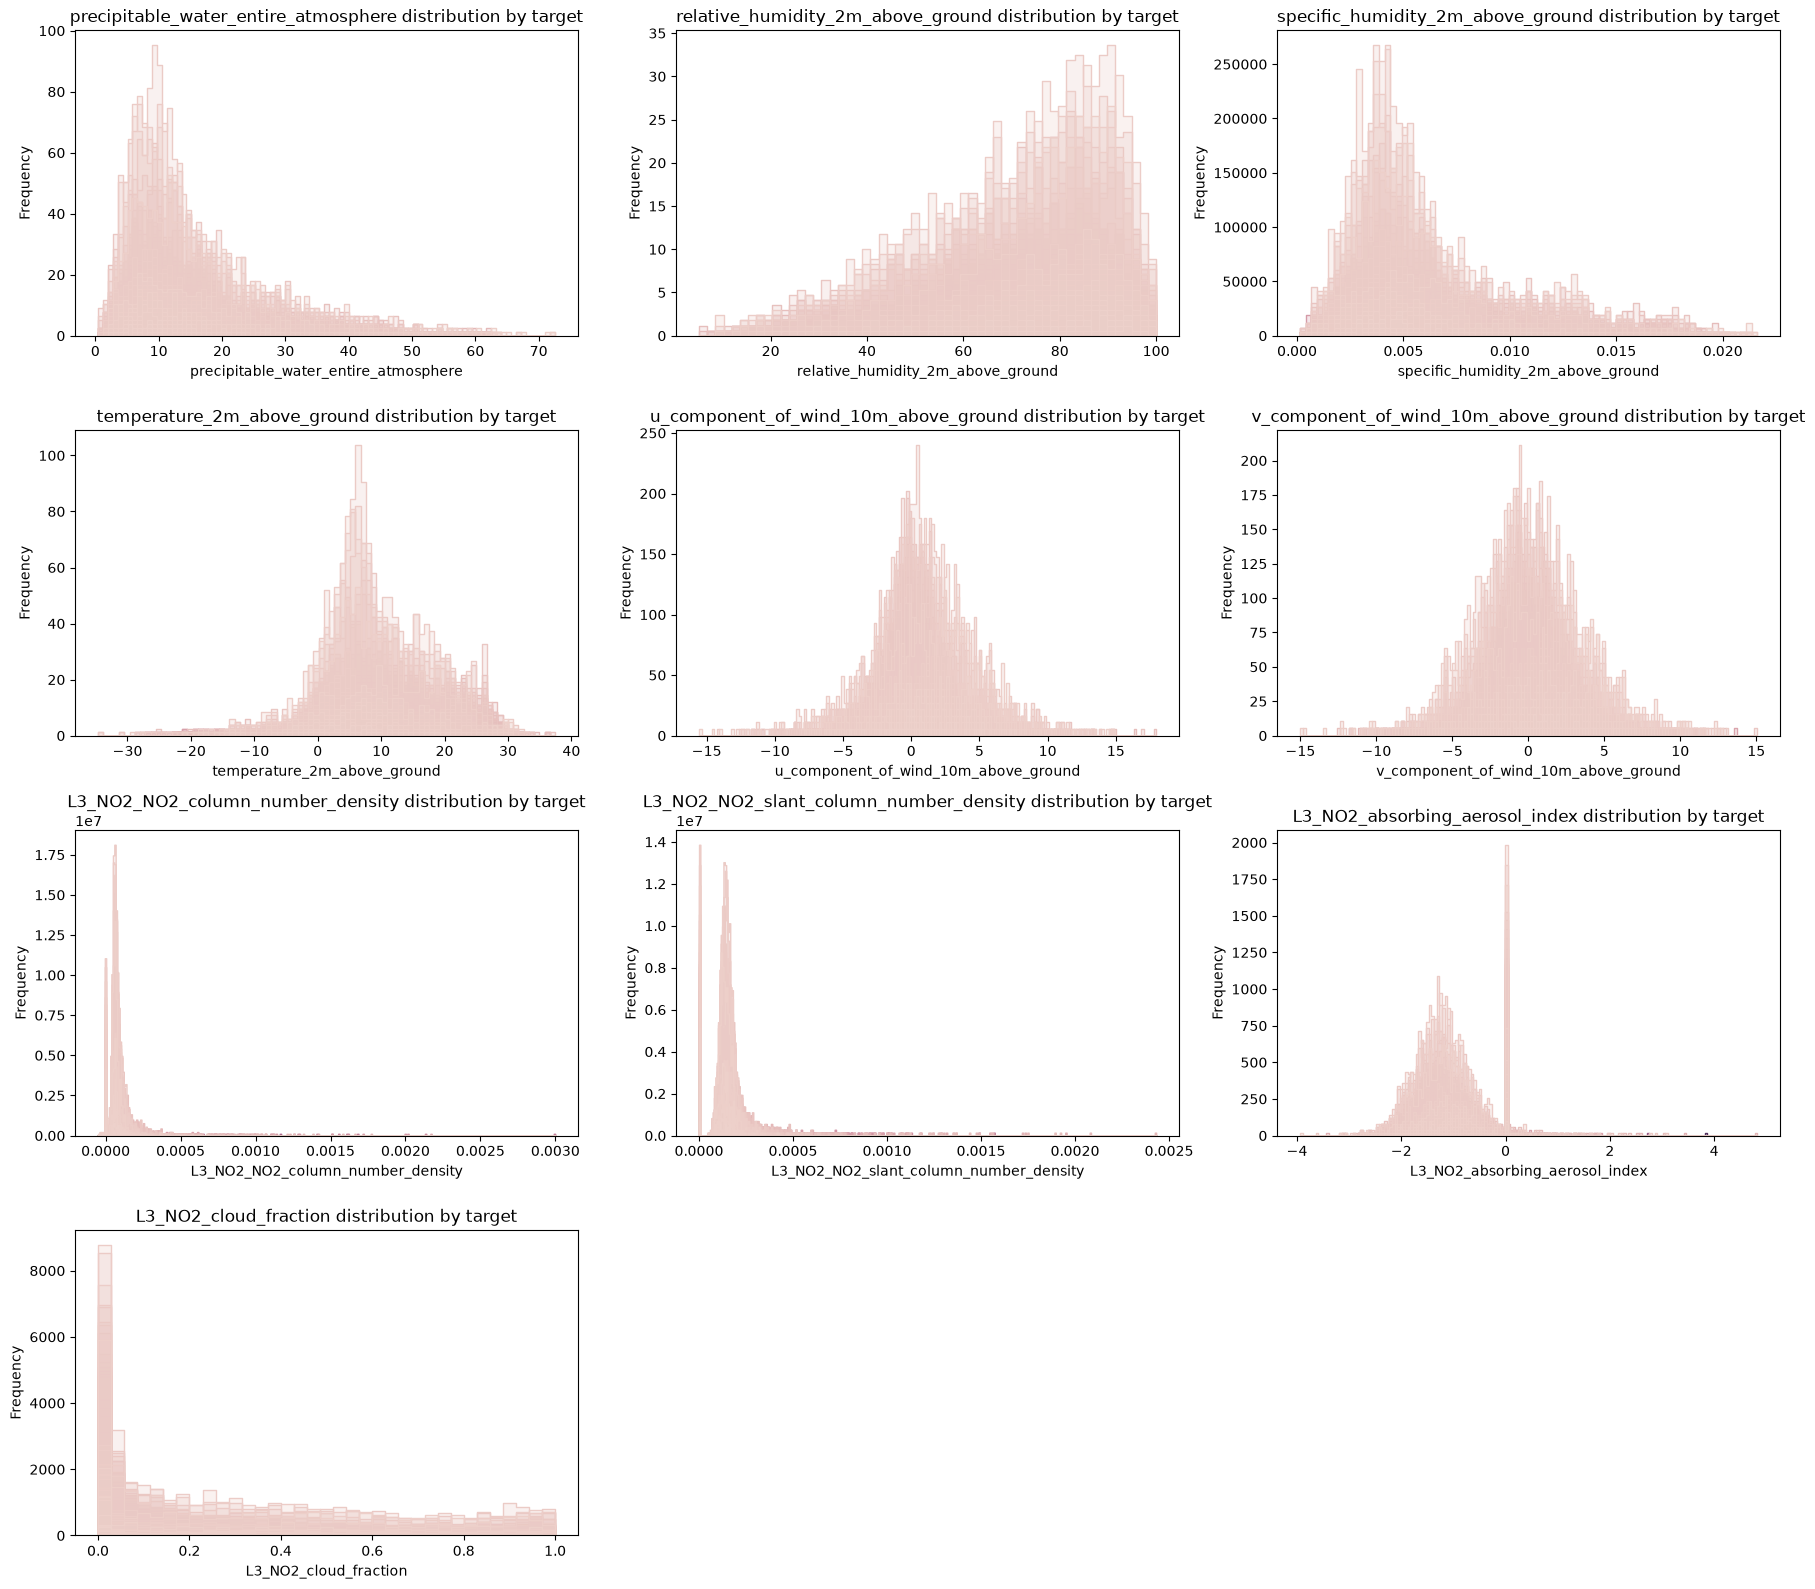

In [11]:
numerical_features = X_train1.select_dtypes(include=np.number).columns.tolist()
plot_data = X_train1.copy()
plot_data["target"] = y_train1

# Optional: use only the first 10 features
numerical_features = numerical_features[:10]

n_features = len(numerical_features)
n_columns = 3
n_rows = int(np.ceil(n_features / n_columns))

fig, axes = plt.subplots(
	n_rows,
	n_columns,
	figsize=(18, 4 * n_rows),
	squeeze=False
)
axes = axes.ravel()

for axis, column in zip(axes, numerical_features):
	sns.histplot(
		data=plot_data,
		x=column,
		hue="target",
		kde=False,
		element="step",
		stat="frequency",
		common_norm=False,
		ax=axis,
		legend=False
	)
	axis.set_title(f"{column} distribution by target")

for axis in axes[n_features:]:
	axis.remove()

plt.tight_layout()
plt.show()

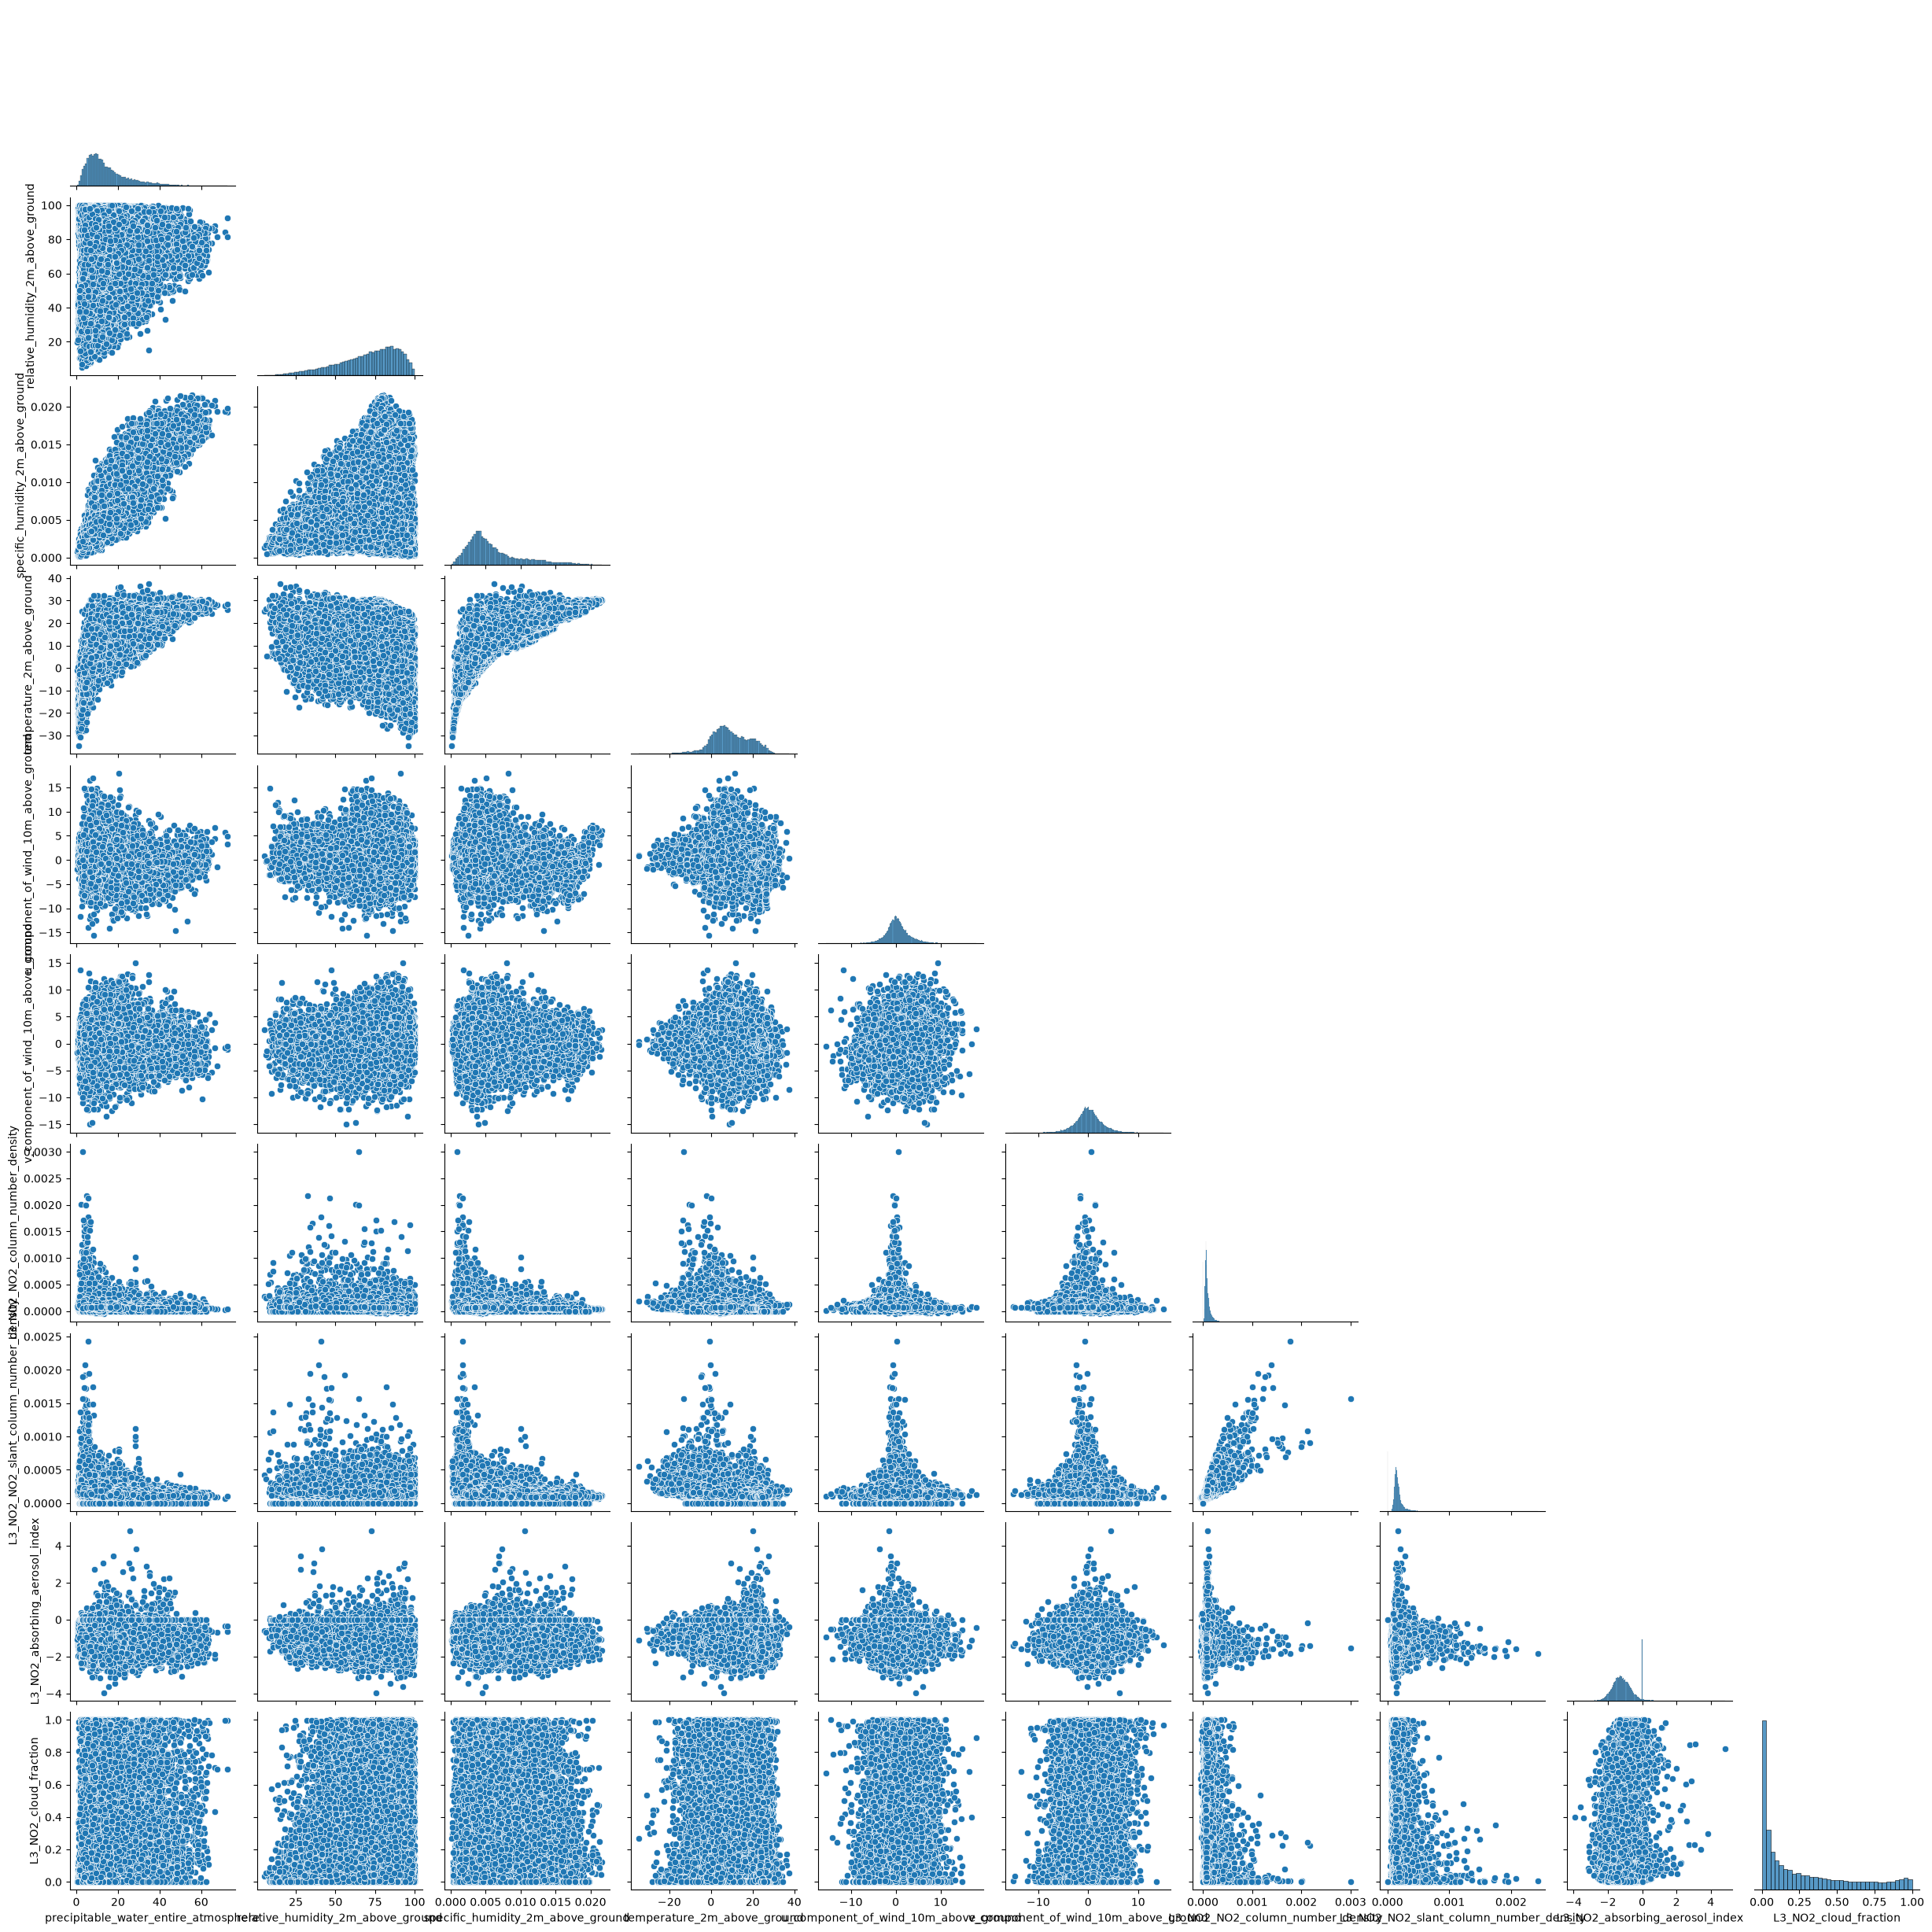

In [12]:
# Get numerical features
numerical_features = X_train1.select_dtypes(include=np.number).columns

# Select the first 10 numerical features
first_10_features = X_train1[numerical_features[:10]]

# Create pairplot
sns.pairplot(
    first_10_features,
    corner=True,
    diag_kind="hist"
)

plt.show()

In [13]:
missing_summary = pd.DataFrame({
    "missing_count": X_train1.isna().sum(),
    "missing_percentage": X_train1.isna().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percentage
L3_CH4_solar_zenith_angle,24765,81.045260
L3_CH4_sensor_zenith_angle,24765,81.045260
L3_CH4_sensor_azimuth_angle,24765,81.045260
L3_CH4_aerosol_height,24765,81.045260
L3_CH4_CH4_column_volume_mixing_ratio_dry_air,24765,81.045260
...,...,...
L3_AER_AI_solar_azimuth_angle,197,0.644697
L3_AER_AI_sensor_altitude,197,0.644697
L3_AER_AI_absorbing_aerosol_index,197,0.644697
L3_AER_AI_sensor_zenith_angle,197,0.644697


In [14]:
# Descriptive statistics
display(X_train1.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
precipitable_water_entire_atmosphere,30557.0,15.30,10.69,0.42,7.67,12.20,19.90,72.60
relative_humidity_2m_above_ground,30557.0,70.55,18.81,5.13,58.60,74.10,85.45,100.00
specific_humidity_2m_above_ground,30557.0,0.01,0.00,0.00,0.00,0.00,0.01,0.02
temperature_2m_above_ground,30557.0,9.32,9.34,-34.65,3.12,8.48,16.20,37.44
u_component_of_wind_10m_above_ground,30557.0,0.42,2.71,-15.56,-1.10,0.22,1.77,17.96
...,...,...,...,...,...,...,...,...
L3_CH4_aerosol_optical_depth,5792.0,0.02,0.03,0.00,0.00,0.00,0.02,0.21
L3_CH4_sensor_azimuth_angle,5792.0,1.25,55.10,-105.37,0.00,0.00,62.25,77.36
L3_CH4_sensor_zenith_angle,5792.0,13.85,18.00,0.00,0.00,0.00,27.41,59.97
L3_CH4_solar_azimuth_angle,5792.0,-69.10,84.70,-179.95,-161.73,0.00,0.00,179.81


In [15]:
display(X_train1.nunique().sort_values().rename('n_unique').to_frame())

,n_unique
L3_CH4_aerosol_height,2874
L3_CH4_solar_zenith_angle,2874
L3_CH4_solar_azimuth_angle,2874
L3_CH4_sensor_zenith_angle,2874
L3_CH4_sensor_azimuth_angle,2874
...,...
L3_AER_AI_sensor_altitude,30360
L3_AER_AI_sensor_azimuth_angle,30360
L3_AER_AI_sensor_zenith_angle,30360
L3_AER_AI_solar_zenith_angle,30360


<class 'pandas.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 74 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   precipitable_water_entire_atmosphere                 30557 non-null  float64
 1   relative_humidity_2m_above_ground                    30557 non-null  float64
 2   specific_humidity_2m_above_ground                    30557 non-null  float64
 3   temperature_2m_above_ground                          30557 non-null  float64
 4   u_component_of_wind_10m_above_ground                 30557 non-null  float64
 5   v_component_of_wind_10m_above_ground                 30557 non-null  float64
 6   L3_NO2_NO2_column_number_density                     28368 non-null  float64
 7   L3_NO2_NO2_slant_column_number_density               28368 non-null  float64
 8   L3_NO2_absorbing_aerosol_index                       28368 non-null  float64


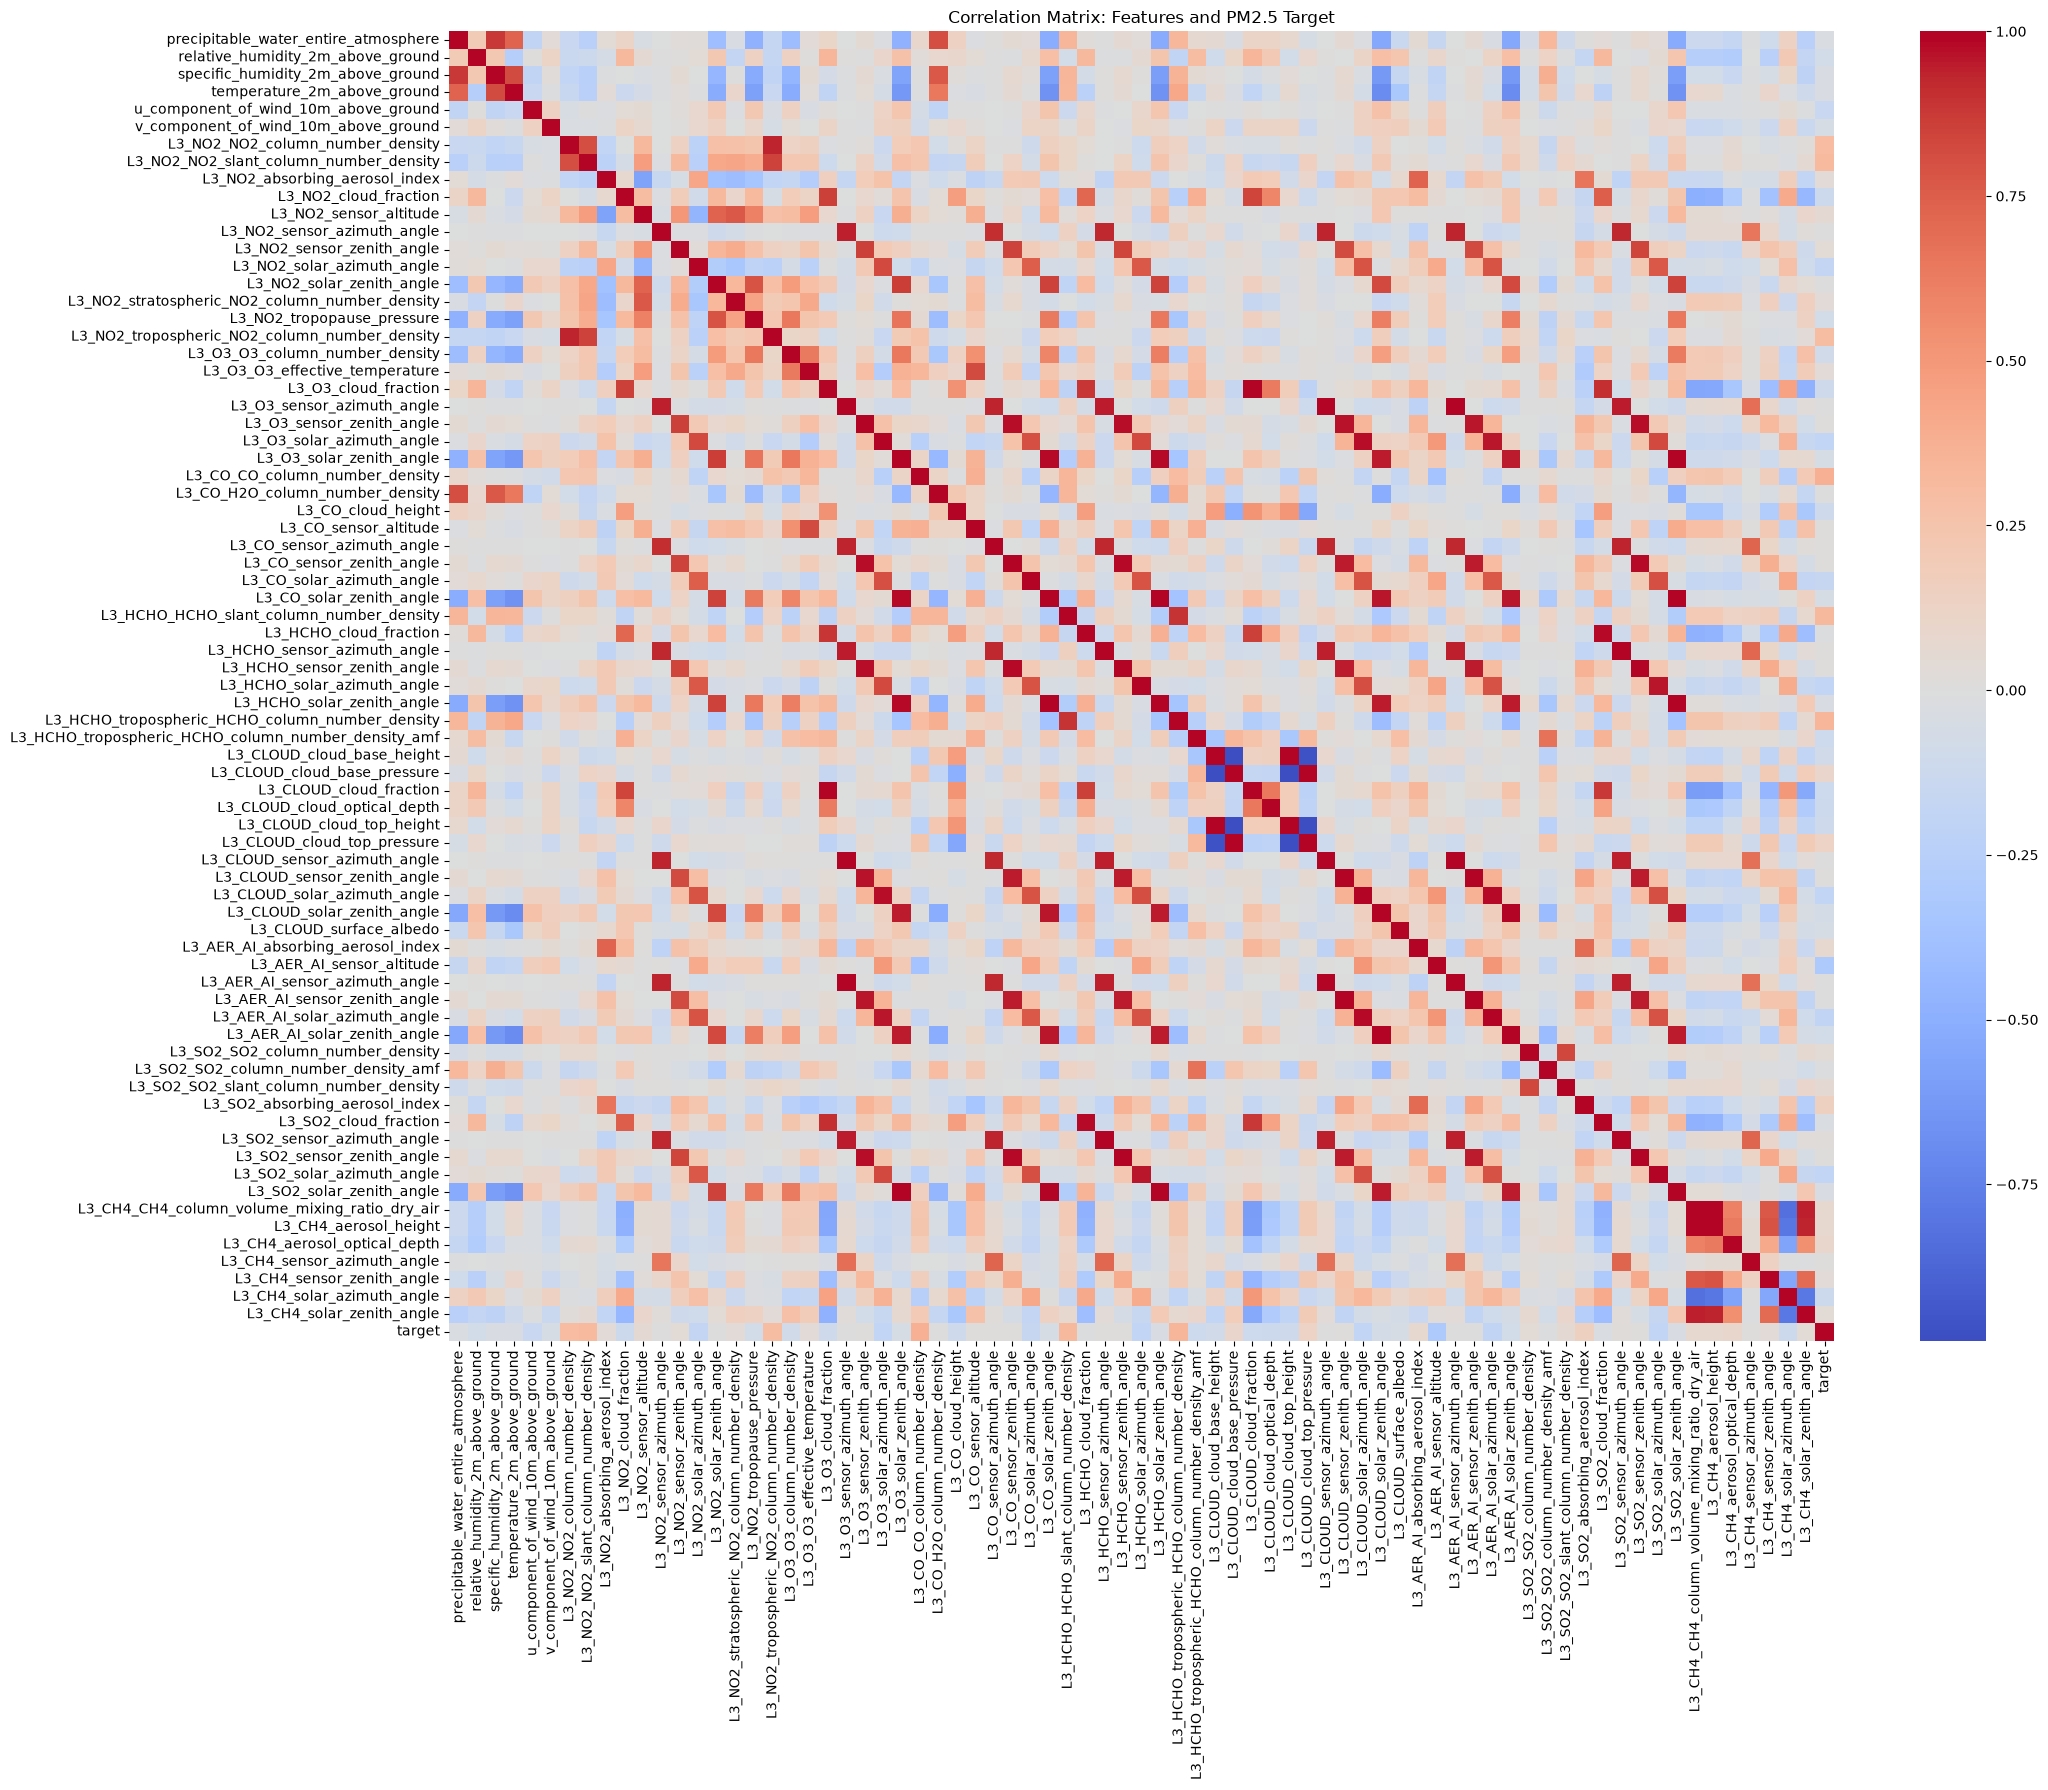

In [16]:
# Explore the Training Data
X_train1.info()

# Correlation of each feature with the target
feature_target_correlation = X_train1.corrwith(y_train1).sort_values(ascending=False)
feature_target_correlation

# Full correlation matrix for all features and the target
correlation_matrix = pd.concat(
    [X_train1, y_train1.rename("target")],
    axis=1
).corr()
correlation_matrix

# Visualize the full correlation matrix
plt.figure(figsize=(22, 18))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Features and PM2.5 Target")
plt.tight_layout()
plt.show()

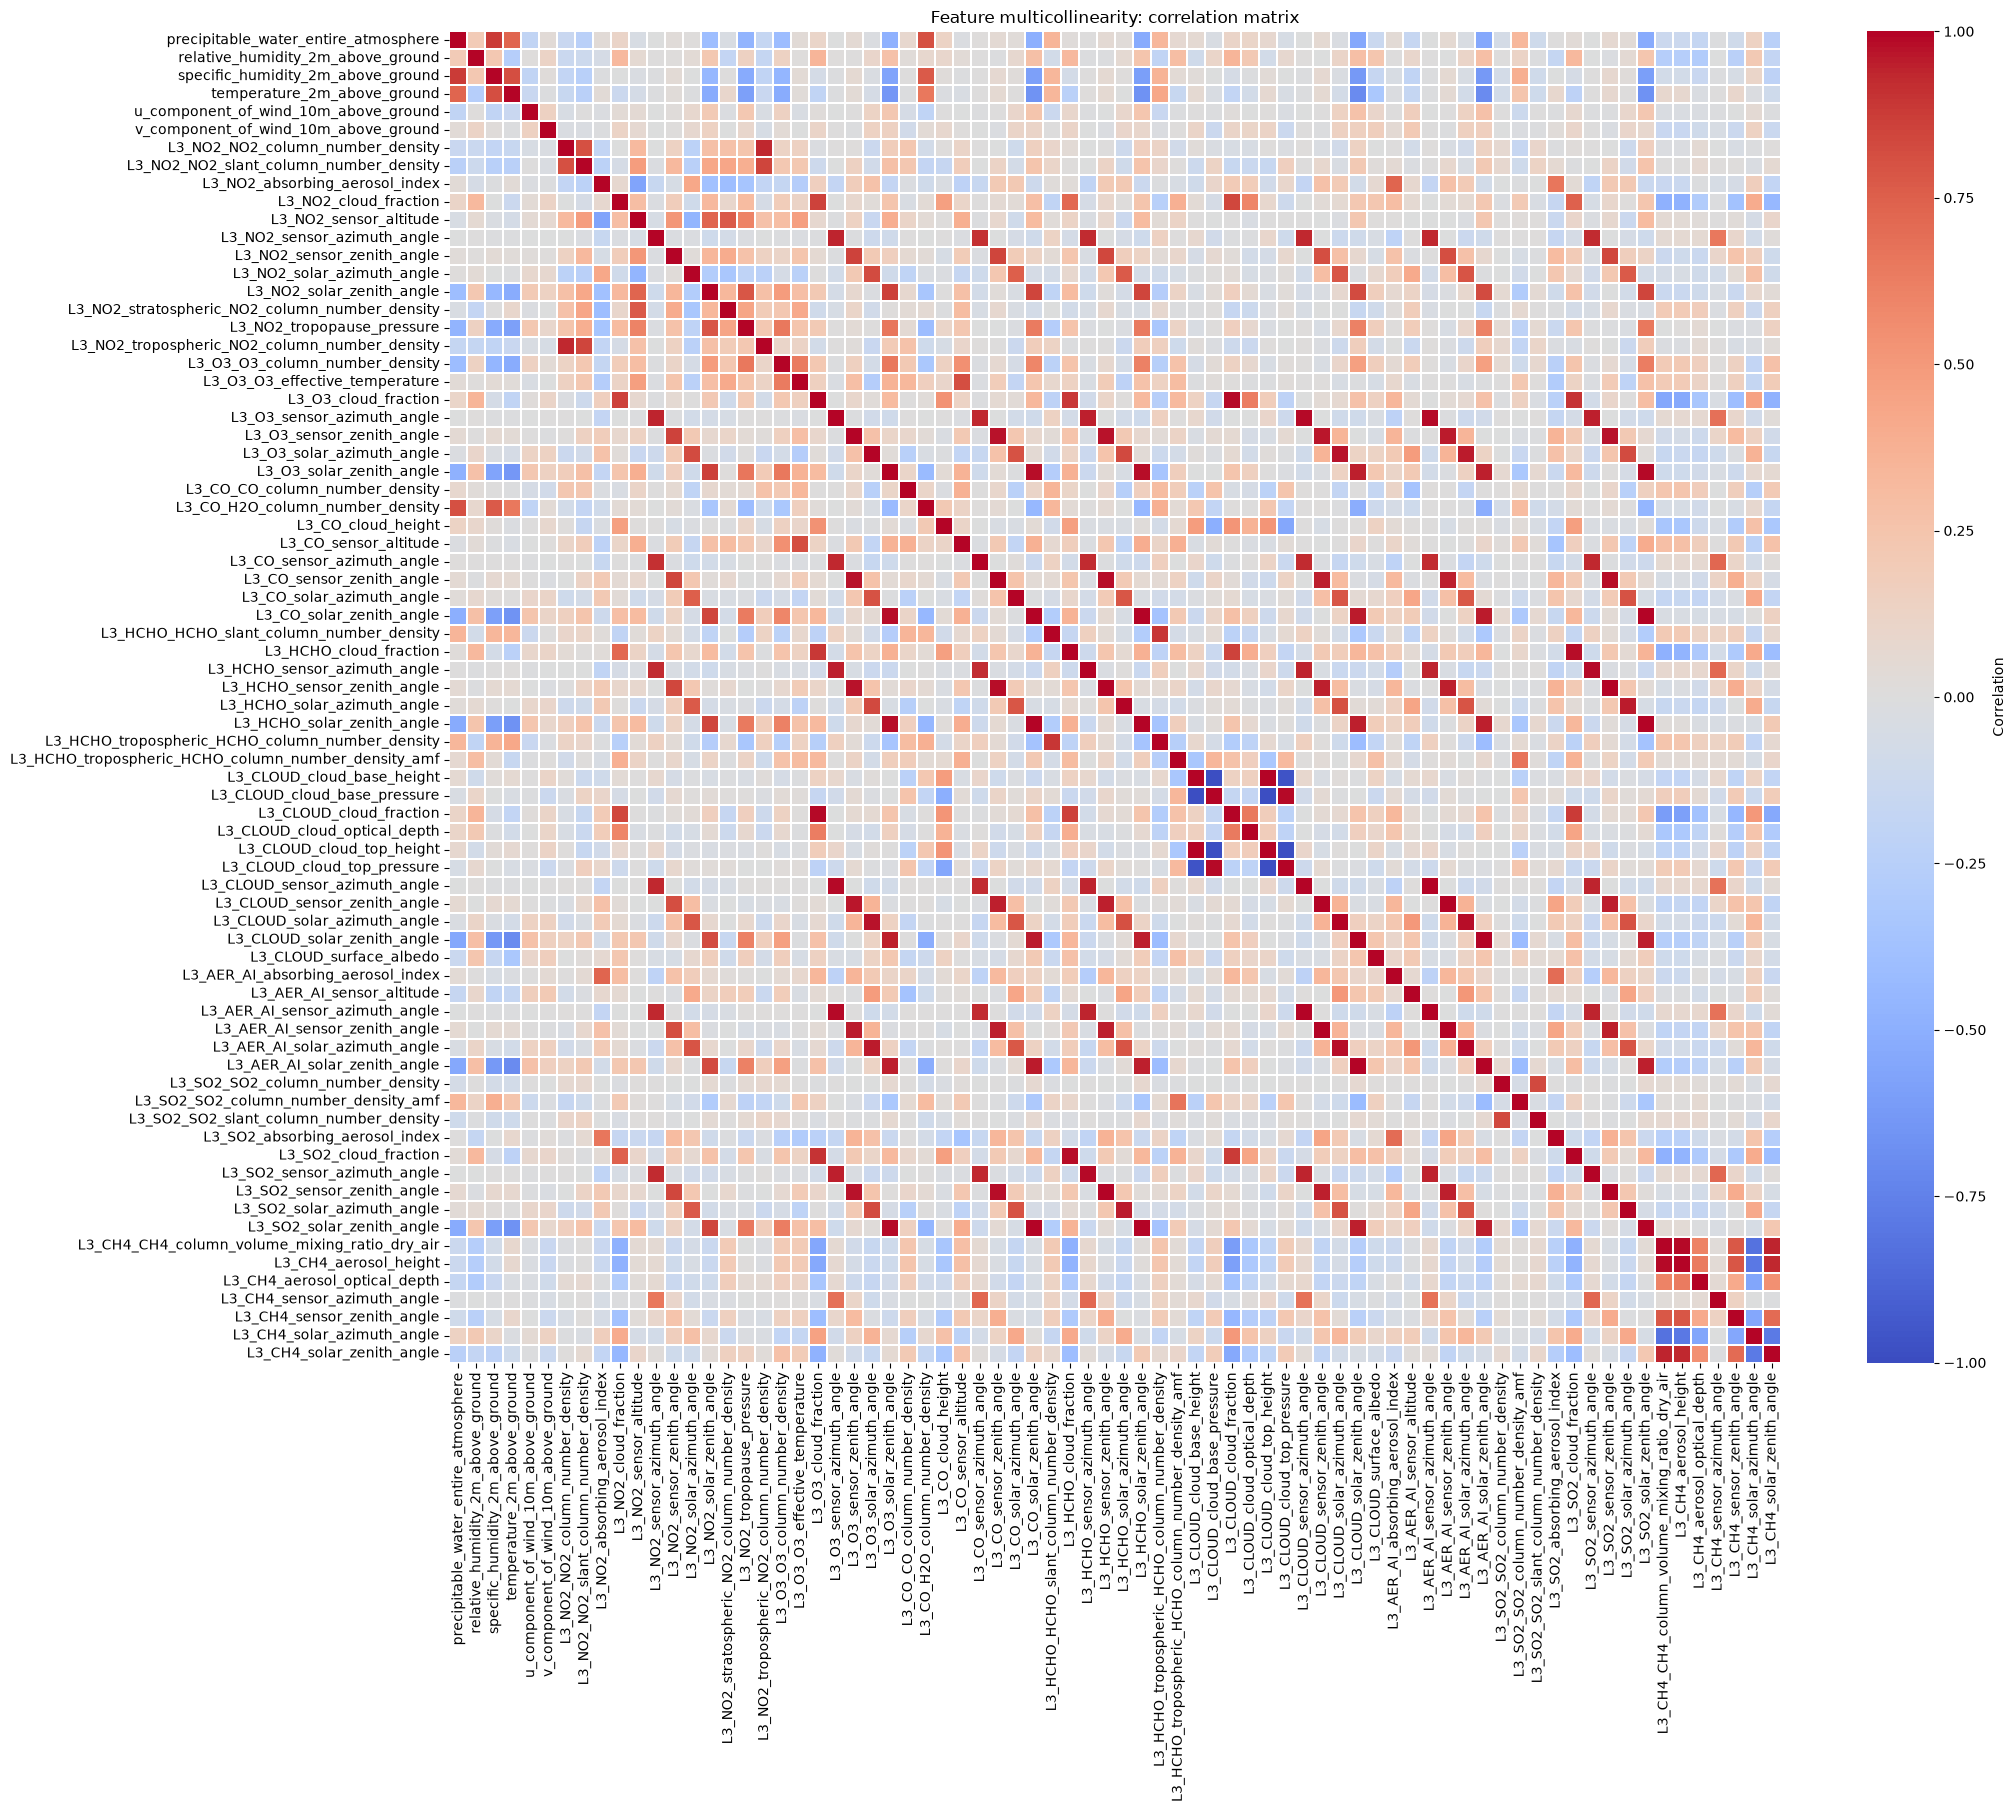

Highly correlated feature pairs (|correlation| >= 0.95):


,feature_1,feature_2,correlation
0,L3_CLOUD_solar_zenith_angle,L3_AER_AI_solar_zenith_angle,1.000
1,L3_HCHO_solar_zenith_angle,L3_SO2_solar_zenith_angle,1.000
2,L3_CO_solar_zenith_angle,L3_HCHO_solar_zenith_angle,0.997
3,L3_CO_solar_zenith_angle,L3_SO2_solar_zenith_angle,0.997
4,L3_CLOUD_sensor_zenith_angle,L3_AER_AI_sensor_zenith_angle,0.997
5,L3_CLOUD_sensor_azimuth_angle,L3_AER_AI_sensor_azimuth_angle,0.995
6,L3_HCHO_sensor_zenith_angle,L3_SO2_sensor_zenith_angle,0.995
7,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_top_height,0.993
8,L3_O3_sensor_azimuth_angle,L3_CLOUD_sensor_azimuth_angle,0.991
9,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,0.990


In [44]:
# Show the multicollinearity of the numerical features
numeric_data = X_train1.select_dtypes(include=np.number)
feature_correlation = numeric_data.corr()

plt.figure(figsize=(22, 18))
sns.heatmap(
    feature_correlation,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"label": "Correlation"},
)
plt.title("Feature multicollinearity: correlation matrix")
plt.tight_layout()
plt.show()

# List highly correlated feature pairs without duplicates.
correlation_threshold = 0.95
upper_triangle = feature_correlation.where(
    np.triu(np.ones(feature_correlation.shape), k=1).astype(bool)
 )
high_correlation_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(
        columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
            0: "correlation",
        }
    )
    .assign(abs_correlation=lambda data: data["correlation"].abs())
    .query("abs_correlation >= @correlation_threshold")
    .sort_values("abs_correlation", ascending=False)
    .drop(columns="abs_correlation")
    .reset_index(drop=True)
 )

print(f"Highly correlated feature pairs (|correlation| >= {correlation_threshold}):")
display(high_correlation_pairs.round(3))

In [17]:
X_train1.dtypes

precipitable_water_entire_atmosphere    float64
relative_humidity_2m_above_ground       float64
specific_humidity_2m_above_ground       float64
temperature_2m_above_ground             float64
u_component_of_wind_10m_above_ground    float64
                                         ...   
L3_CH4_aerosol_optical_depth            float64
L3_CH4_sensor_azimuth_angle             float64
L3_CH4_sensor_zenith_angle              float64
L3_CH4_solar_azimuth_angle              float64
L3_CH4_solar_zenith_angle               float64
Length: 74, dtype: object

In [ ]:
# Feature Engineering
# Copy the original training data
features = train.drop(
    columns=[
        "target",
        "target_min",
        "target_max",
        "target_variance",
        "target_count",
        "Place_ID X Date",
    ]
).copy()

# multicollinear features
multicollinear_features_to_remove = (
    high_correlation_pairs["feature_1"].drop_duplicates().tolist()
) 
# Date features
features["Date"] = pd.to_datetime(features["Date"])
features["year"] = features["Date"].dt.year

# Wind features
features["wind_speed"] = np.sqrt(
    features["u_component_of_wind_10m_above_ground"] ** 2
    + features["v_component_of_wind_10m_above_ground"] ** 2
)

features["wind_direction"] = np.arctan2(
    features["v_component_of_wind_10m_above_ground"],
    features["u_component_of_wind_10m_above_ground"]
)

# Interaction features
features["temperature_humidity"] = (
    features["temperature_2m_above_ground"]
    * features["relative_humidity_2m_above_ground"]
)

features["cloud_aerosol_interaction"] = (
    features["L3_CLOUD_cloud_fraction"]
    * features["L3_AER_AI_absorbing_aerosol_index"]
)

# Remove columns that should not be direct model features
columns_to_remove = [
    "Date",
    "Place_ID",
    "u_component_of_wind_10m_above_ground",
    "v_component_of_wind_10m_above_ground",
    "L3_CLOUD_cloud_fraction",
    "L3_AER_AI_absorbing_aerosol_index",
    "month",
    "day_of_year",
    "day_of_week",
    "month_sin",
    "month_cos",
    "year",
]+ multicollinear_features_to_remove

X_train = features.drop(columns=columns_to_remove, errors="ignore")
y_train = train["target"]

In [56]:
print("X_train feature :", X_train.columns.tolist())  
X_train.head()
X_train.dtypes


X_train feature : ['precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground', 'L3_NO2_NO2_column_number_density', 'L3_NO2_NO2_slant_column_number_density', 'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction', 'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle', 'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle', 'L3_NO2_solar_zenith_angle', 'L3_NO2_stratospheric_NO2_column_number_density', 'L3_NO2_tropopause_pressure', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature', 'L3_CO_CO_column_number_density', 'L3_CO_H2O_column_number_density', 'L3_CO_cloud_height', 'L3_CO_sensor_altitude', 'L3_CO_sensor_azimuth_angle', 'L3_CO_solar_azimuth_angle', 'L3_HCHO_HCHO_slant_column_number_density', 'L3_HCHO_tropospheric_HCHO_column_number_density', 'L3_HCHO_tropospheric_HCHO_column_number_density_amf', 'L3_CLOUD_cloud_optical_depth',

precipitable_water_entire_atmosphere                   float64
relative_humidity_2m_above_ground                      float64
specific_humidity_2m_above_ground                      float64
temperature_2m_above_ground                            float64
L3_NO2_NO2_column_number_density                       float64
L3_NO2_NO2_slant_column_number_density                 float64
L3_NO2_absorbing_aerosol_index                         float64
L3_NO2_cloud_fraction                                  float64
L3_NO2_sensor_altitude                                 float64
L3_NO2_sensor_azimuth_angle                            float64
L3_NO2_sensor_zenith_angle                             float64
L3_NO2_solar_azimuth_angle                             float64
L3_NO2_solar_zenith_angle                              float64
L3_NO2_stratospheric_NO2_column_number_density         float64
L3_NO2_tropopause_pressure                             float64
L3_NO2_tropospheric_NO2_column_number_density          

In [55]:
y_train.head()

6892     105.0
28239     38.0
15726     30.0
1413      59.0
30488     55.0
Name: target, dtype: float64

In [58]:
test.head()

,Place_ID X Date,Date,Place_ID,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,0OS9LVX X 2020-01-02,2020-01-02,0OS9LVX,11.600000,30.200001,0.00409,14.656824,3.956377,0.712605,0.000053,...,1.445658,-95.984984,22.942019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0OS9LVX X 2020-01-03,2020-01-03,0OS9LVX,18.300001,42.900002,0.00595,15.026544,4.230430,0.661892,0.000050,...,34.641758,-95.014908,18.539116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0OS9LVX X 2020-01-04,2020-01-04,0OS9LVX,17.600000,41.299999,0.00590,15.511041,5.245728,1.640559,0.000050,...,55.872276,-94.015418,14.140820,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0OS9LVX X 2020-01-05,2020-01-05,0OS9LVX,15.011948,53.100002,0.00709,14.441858,5.454001,-0.190532,0.000055,...,59.174188,-97.247602,32.730553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0OS9LVX X 2020-01-06,2020-01-06,0OS9LVX,9.700000,71.599998,0.00808,11.896295,3.511787,-0.279441,0.000055,...,40.925873,-96.057265,28.320527,1831.261597,3229.118652,0.031068,-100.278343,41.84708,-95.910744,28.498789


In [59]:
X_test1 = test.drop(
    columns=["Place_ID X Date", "Place_ID", 'Date']
).copy()

print("X_test1 feature :", X_test1.columns.tolist())
X_test1.head()

X_test1 feature : ['precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground', 'u_component_of_wind_10m_above_ground', 'v_component_of_wind_10m_above_ground', 'L3_NO2_NO2_column_number_density', 'L3_NO2_NO2_slant_column_number_density', 'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction', 'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle', 'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle', 'L3_NO2_solar_zenith_angle', 'L3_NO2_stratospheric_NO2_column_number_density', 'L3_NO2_tropopause_pressure', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature', 'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle', 'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle', 'L3_O3_solar_zenith_angle', 'L3_CO_CO_column_number_density', 'L3_CO_H2O_column_number_density', 'L3_CO_cloud_height', 'L3_CO_sensor_altitude', 'L3_CO_sensor_azimut

,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,11.600000,30.200001,0.00409,14.656824,3.956377,0.712605,0.000053,0.000108,0.466171,0.010752,...,1.445658,-95.984984,22.942019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18.300001,42.900002,0.00595,15.026544,4.230430,0.661892,0.000050,0.000109,-0.213659,0.028307,...,34.641758,-95.014908,18.539116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17.600000,41.299999,0.00590,15.511041,5.245728,1.640559,0.000050,0.000134,-0.254250,0.010374,...,55.872276,-94.015418,14.140820,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,15.011948,53.100002,0.00709,14.441858,5.454001,-0.190532,0.000055,0.000155,-0.268490,0.088795,...,59.174188,-97.247602,32.730553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9.700000,71.599998,0.00808,11.896295,3.511787,-0.279441,0.000055,0.000131,0.460720,0.041197,...,40.925873,-96.057265,28.320527,1831.261597,3229.118652,0.031068,-100.278343,41.84708,-95.910744,28.498789


In [60]:
X_test1.dtypes

precipitable_water_entire_atmosphere    float64
relative_humidity_2m_above_ground       float64
specific_humidity_2m_above_ground       float64
temperature_2m_above_ground             float64
u_component_of_wind_10m_above_ground    float64
                                         ...   
L3_CH4_aerosol_optical_depth            float64
L3_CH4_sensor_azimuth_angle             float64
L3_CH4_sensor_zenith_angle              float64
L3_CH4_solar_azimuth_angle              float64
L3_CH4_solar_zenith_angle               float64
Length: 74, dtype: object

In [61]:
# Feature engineering: Copy the original test data
features_test = test.drop(
    columns=[
        "Place_ID X Date", "Place_ID"
    ]
).copy()

# multicollinear features
multicollinear_features_to_remove = (
    high_correlation_pairs["feature_1"].drop_duplicates().tolist()
)

# Date features
features_test["Date"] = pd.to_datetime(features_test["Date"])
features_test["year"] = features_test["Date"].dt.year

# Wind features
features_test["wind_speed"] = np.sqrt(
    features_test["u_component_of_wind_10m_above_ground"] ** 2
    + features_test["v_component_of_wind_10m_above_ground"] ** 2
)

features_test["wind_direction"] = np.arctan2(
    features_test["v_component_of_wind_10m_above_ground"],
    features_test["u_component_of_wind_10m_above_ground"]
)

# Interaction features
features_test["temperature_humidity"] = (
    features_test["temperature_2m_above_ground"]
    * features_test["relative_humidity_2m_above_ground"]
)

features_test["cloud_aerosol_interaction"] = (
    features_test["L3_CLOUD_cloud_fraction"]
    * features_test["L3_AER_AI_absorbing_aerosol_index"]
)

# Keep test features identical to the training feature schema
columns_to_remove = [
    "Date",
    "u_component_of_wind_10m_above_ground",
    "v_component_of_wind_10m_above_ground",
    "L3_CLOUD_cloud_fraction",
    "L3_AER_AI_absorbing_aerosol_index",
    "month",
    "day_of_year",
    "day_of_week",
    "month_sin",
    "month_cos",
    "year",
]+ multicollinear_features_to_remove

X_test = features_test.drop(columns=columns_to_remove, errors="ignore")

In [62]:
print("X_test feature :", X_test.columns.tolist())
X_test.dtypes

X_test feature : ['precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground', 'L3_NO2_NO2_column_number_density', 'L3_NO2_NO2_slant_column_number_density', 'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction', 'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle', 'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle', 'L3_NO2_solar_zenith_angle', 'L3_NO2_stratospheric_NO2_column_number_density', 'L3_NO2_tropopause_pressure', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature', 'L3_CO_CO_column_number_density', 'L3_CO_H2O_column_number_density', 'L3_CO_cloud_height', 'L3_CO_sensor_altitude', 'L3_CO_sensor_azimuth_angle', 'L3_CO_solar_azimuth_angle', 'L3_HCHO_HCHO_slant_column_number_density', 'L3_HCHO_tropospheric_HCHO_column_number_density', 'L3_HCHO_tropospheric_HCHO_column_number_density_amf', 'L3_CLOUD_cloud_optical_depth', 

precipitable_water_entire_atmosphere                   float64
relative_humidity_2m_above_ground                      float64
specific_humidity_2m_above_ground                      float64
temperature_2m_above_ground                            float64
L3_NO2_NO2_column_number_density                       float64
L3_NO2_NO2_slant_column_number_density                 float64
L3_NO2_absorbing_aerosol_index                         float64
L3_NO2_cloud_fraction                                  float64
L3_NO2_sensor_altitude                                 float64
L3_NO2_sensor_azimuth_angle                            float64
L3_NO2_sensor_zenith_angle                             float64
L3_NO2_solar_azimuth_angle                             float64
L3_NO2_solar_zenith_angle                              float64
L3_NO2_stratospheric_NO2_column_number_density         float64
L3_NO2_tropopause_pressure                             float64
L3_NO2_tropospheric_NO2_column_number_density          

In [63]:
X_test.head

<bound method NDFrame.head of        precipitable_water_entire_atmosphere  \
0                                 11.600000   
1                                 18.300001   
2                                 17.600000   
3                                 15.011948   
4                                  9.700000   
...                                     ...   
16131                              9.400001   
16132                             17.000000   
16133                             19.170641   
16134                              8.400001   
16135                              6.500000   

       relative_humidity_2m_above_ground  specific_humidity_2m_above_ground  \
0                              30.200001                            0.00409   
1                              42.900002                            0.00595   
2                              41.299999                            0.00590   
3                              53.100002                            0.00709   
4         

In [ ]:
# Train-validation split
# The separate X_test 
# dataset should remain untouched until final predictions.
RANDOM_STATE = 42

X = X_train.copy()
y = y_train.copy()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Keep both naming conventions used elsewhere in the notebook
x_train = X_train
x_val = X_val

print(f"X training: {X_train.shape}")
print(f"X validation: {X_val.shape}")
print(f"y training: {y_train.shape}")
print(f"y validation: {y_val.shape}")

X training: (19556, 54)
X validation: (4889, 54)
y training: (19556,)
y validation: (4889,)


In [78]:
# Build regression pipelines
numeric_features = x_train.select_dtypes(include=np.number).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[(
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        )
    ],
    remainder="drop",
)

def make_pipeline(estimator):
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator),
    ])

models = {
    "Random forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "KNN": KNeighborsRegressor(n_neighbors=10, weights="distance"),
    "Linear regression": LinearRegression(),
}

fitted_models = {}
model_rows = []

for name, estimator in models.items():
    model = make_pipeline(estimator)
    model.fit(x_train, y_train)
    fitted_models[name] = model

    train_predictions = model.predict(x_train)
    validation_predictions = model.predict(x_val)

    model_rows.append({
        "model": name,
        "train_rmse": np.sqrt(mean_squared_error(y_train, train_predictions)),
        "validation_rmse": np.sqrt(mean_squared_error(y_val, validation_predictions)),
        "validation_mae": mean_absolute_error(y_val, validation_predictions),
        "validation_r2": r2_score(y_val, validation_predictions),
    })

print("Regression pipeline objects:")
for name, pipeline in fitted_models.items():
    print(f"\n{name}:")
    display(pipeline)

results = pd.DataFrame(model_rows).sort_values("validation_rmse")
display(results.round(3))

Regression pipeline objects:

Random forest:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](54,)","['precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground','specific_humidity_2m_above_ground', ...,'wind_direction','temperature_humidity','cloud_aerosol_interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,54
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformer


KNN:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](54,)","['precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground','specific_humidity_2m_above_ground', ...,'wind_direction','temperature_humidity','cloud_aerosol_interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,54
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformer


Linear regression:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](54,)","['precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground','specific_humidity_2m_above_ground', ...,'wind_direction','temperature_humidity','cloud_aerosol_interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,54
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformer

,model,train_rmse,validation_rmse,validation_mae,validation_r2
0,Random forest,13.977,29.482,20.491,0.596
1,KNN,0.000,33.628,23.566,0.474
2,Linear regression,36.587,35.257,25.961,0.422


In [66]:
# Validation metrics for the three regression pipelines
model_rows = []
for name, model in fitted_models.items():
    validation_predictions = model.predict(X_val)
    model_rows.append({
        "model": name,
        "validation_rmse": np.sqrt(mean_squared_error(y_val, validation_predictions)),
        "validation_mae": mean_absolute_error(y_val, validation_predictions),
        "validation_r2": r2_score(y_val, validation_predictions),
    })

results = pd.DataFrame(model_rows).sort_values("validation_rmse")
display(results.round(3))

,model,validation_rmse,validation_mae,validation_r2
0,Random forest,29.482,20.491,0.596
1,KNN,33.628,23.566,0.474
2,Linear regression,35.257,25.961,0.422


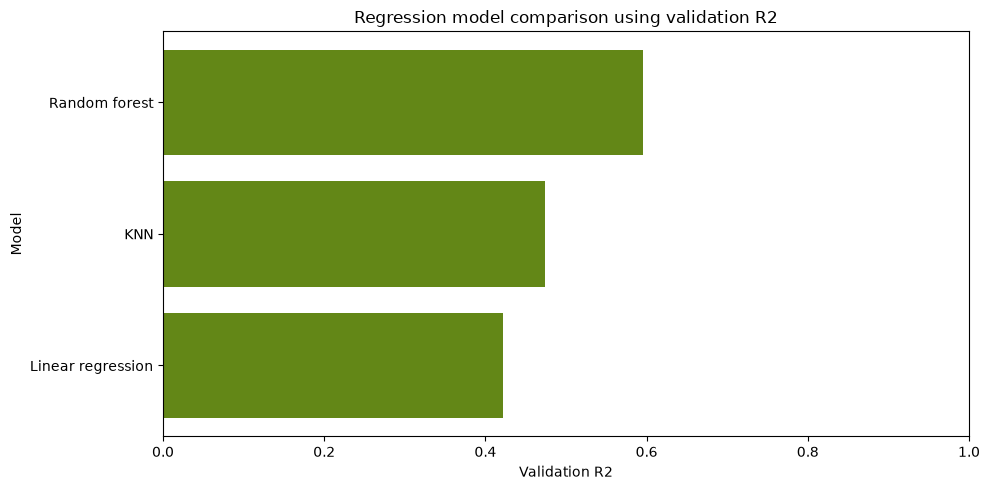

In [68]:
# Compare validation R2
plot_data = results.sort_values("validation_r2", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(
    plot_data["model"],
    plot_data["validation_r2"],
    color="#638717",
)
plt.xlabel("Validation R2")
plt.ylabel("Model")
plt.title("Regression model comparison using validation R2")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# Improve the models with GridSearchCV and feature selection
# All searches use only x_train and y_train; x_val remains unseen until final evaluation.

cv_folds = 2

# Test a range of selected feature counts for every regression model.
feature_counts = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]

feature_selection_models = {}
feature_selection_summaries = []

for model_name, estimator in models.items():
    feature_selection_pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("select", SelectKBest(score_func=f_regression)),
        ("model", estimator),
    ])

    feature_selection_search = GridSearchCV(
        estimator=feature_selection_pipeline,
        param_grid={"select__k": feature_counts},
        scoring="neg_root_mean_squared_error",
        cv=cv_folds,
        n_jobs=-1,
    )
    feature_selection_search.fit(x_train, y_train)

    feature_selection_models[f"Feature-selected {model_name}"] = (
        feature_selection_search.best_estimator_
    )
    feature_selection_summaries.append({
        "model": model_name,
        "best_cv_rmse": -feature_selection_search.best_score_,
        "best_params": feature_selection_search.best_params_,
    })

print("Grid-search results for feature selection across all models:")
display(pd.DataFrame(feature_selection_summaries).round(3))

# Evaluate the feature-selected models on the held-out validation set.
feature_selection_rows = []
for name, model in feature_selection_models.items():
    validation_predictions = model.predict(x_val)
    feature_selection_rows.append({
        "model": name,
        "validation_rmse": np.sqrt(mean_squared_error(y_val, validation_predictions)),
        "validation_mae": mean_absolute_error(y_val, validation_predictions),
        "validation_r2": r2_score(y_val, validation_predictions),
    })

feature_selection_results = pd.DataFrame(feature_selection_rows).sort_values(
        "validation_r2", ascending=False
)
display(feature_selection_results.round(3))

Grid-search results for feature selection across all models:


,model,best_cv_rmse,best_params
0,Random forest,31.970,{'select__k': 40}
1,KNN,34.630,{'select__k': 40}
2,Linear regression,36.809,{'select__k': 55}


,model,validation_rmse,validation_mae,validation_r2
0,Feature-selected Random forest,29.732,20.657,0.589
1,Feature-selected KNN,32.334,22.452,0.514
2,Feature-selected Linear regression,35.257,25.961,0.422


In [70]:
# Top 20 important features for each regression model
# Permutation importance works for Random Forest, KNN, and Linear Regression.
from sklearn.inspection import permutation_importance

importance_tables = {}

for name, model in fitted_models.items():
    permutation_result = permutation_importance(
        model,
        x_val,
        y_val,
        scoring="neg_root_mean_squared_error",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    importance_table = pd.DataFrame({
        "feature": x_val.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }).sort_values("importance_mean", ascending=False)

    importance_tables[name] = importance_table

    print(f"Top 20 important variables - {name}")
    display(importance_table.head(20).round(4))

Top 20 important variables - Random forest


,feature,importance_mean,importance_std
30,L3_AER_AI_sensor_altitude,8.0206,0.1906
18,L3_CO_CO_column_number_density,6.3539,0.3526
50,wind_speed,4.7678,0.1578
25,L3_HCHO_tropospheric_HCHO_column_number_density,2.5419,0.0522
5,L3_NO2_NO2_slant_column_number_density,2.4876,0.1629
4,L3_NO2_NO2_column_number_density,1.2107,0.0448
3,temperature_2m_above_ground,1.1556,0.0452
52,temperature_humidity,1.0209,0.0800
26,L3_HCHO_tropospheric_HCHO_column_number_densit...,0.6931,0.0742
29,L3_CLOUD_surface_albedo,0.5907,0.0273


Top 20 important variables - KNN


,feature,importance_mean,importance_std
50,wind_speed,1.8266,0.0918
18,L3_CO_CO_column_number_density,1.8144,0.0509
25,L3_HCHO_tropospheric_HCHO_column_number_density,0.9643,0.0407
52,temperature_humidity,0.9009,0.1310
5,L3_NO2_NO2_slant_column_number_density,0.8041,0.0981
30,L3_AER_AI_sensor_altitude,0.7961,0.0823
4,L3_NO2_NO2_column_number_density,0.7233,0.0825
3,temperature_2m_above_ground,0.6730,0.0941
1,relative_humidity_2m_above_ground,0.6063,0.1064
14,L3_NO2_tropopause_pressure,0.6060,0.0366


Top 20 important variables - Linear regression


,feature,importance_mean,importance_std
52,temperature_humidity,4.0619,0.1081
5,L3_NO2_NO2_slant_column_number_density,3.4353,0.1569
18,L3_CO_CO_column_number_density,2.8917,0.2073
14,L3_NO2_tropopause_pressure,2.6441,0.1061
50,wind_speed,1.9911,0.0844
30,L3_AER_AI_sensor_altitude,1.9284,0.0551
25,L3_HCHO_tropospheric_HCHO_column_number_density,1.8480,0.0757
12,L3_NO2_solar_zenith_angle,1.8478,0.1344
15,L3_NO2_tropospheric_NO2_column_number_density,1.0237,0.0777
26,L3_HCHO_tropospheric_HCHO_column_number_densit...,0.9755,0.0602


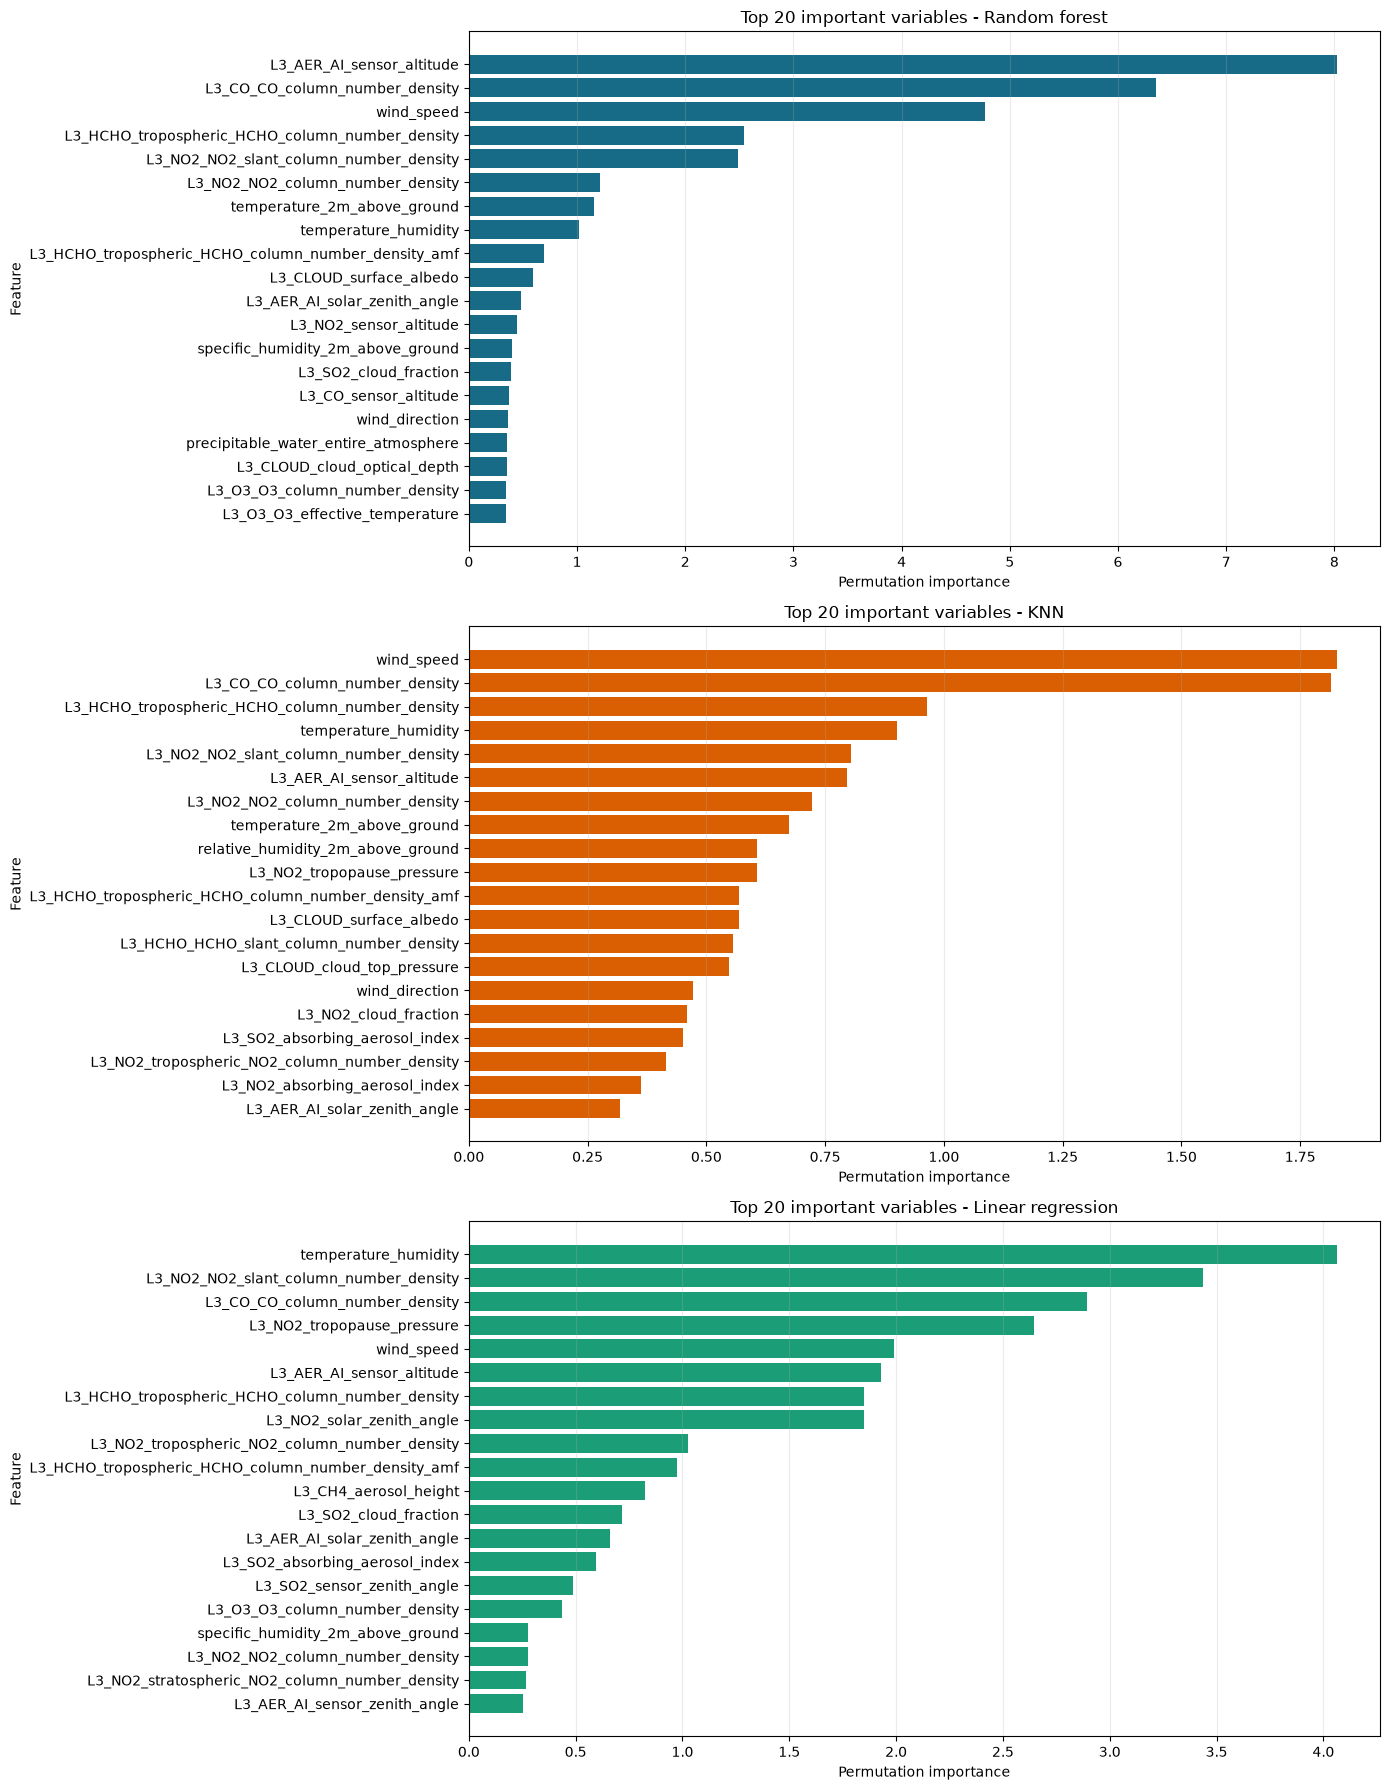

In [71]:
# Plot the top 20 important variables for each model
model_names = list(importance_tables.keys())
figure, axes = plt.subplots(
    nrows=len(model_names),
    ncols=1,
    figsize=(14, 6 * len(model_names)),
    squeeze=False,
)

colors = ["#176b87", "#d95f02", "#1b9e77"]

for axis, (name, color) in zip(axes.ravel(), zip(model_names, colors)):
    top_features = importance_tables[name].head(20).sort_values("importance_mean")

    axis.barh(
        top_features["feature"],
        top_features["importance_mean"],
        color=color,
    )
    axis.set_title(f"Top 20 important variables - {name}")
    axis.set_xlabel("Permutation importance")
    axis.set_ylabel("Feature")
    axis.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [79]:
# Retrain each model using its own 20 most important variables
from sklearn.base import clone

selected_models = {}
selected_rows = []
selected_features_by_model = {}

for name, estimator in models.items():
    top_features = importance_tables[name].head(20)["feature"].tolist()
    selected_features_by_model[name] = top_features

    selected_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                top_features,
            )
        ],
        remainder="drop",
    )

    selected_model = Pipeline([
        ("preprocess", selected_preprocessor),
        ("model", clone(estimator)),
    ])

    selected_model.fit(x_train, y_train)
    selected_models[name] = selected_model

    validation_predictions = selected_model.predict(x_val)
    selected_rows.append({
        "model": name,
        "n_features": len(top_features),
        "validation_rmse": np.sqrt(mean_squared_error(y_val, validation_predictions)),
        "validation_mae": mean_absolute_error(y_val, validation_predictions),
        "validation_r2": r2_score(y_val, validation_predictions),
    })

selected_results = pd.DataFrame(selected_rows).sort_values(
    "validation_r2",
    ascending=False,
 )

print("Validation results using each model's top 20 variables:")
display(selected_results.round(3))

Validation results using each model's top 20 variables:


,model,n_features,validation_rmse,validation_mae,validation_r2
0,Random forest,20,29.359,20.314,0.599
1,KNN,20,31.080,21.340,0.551
2,Linear regression,20,35.609,26.269,0.410


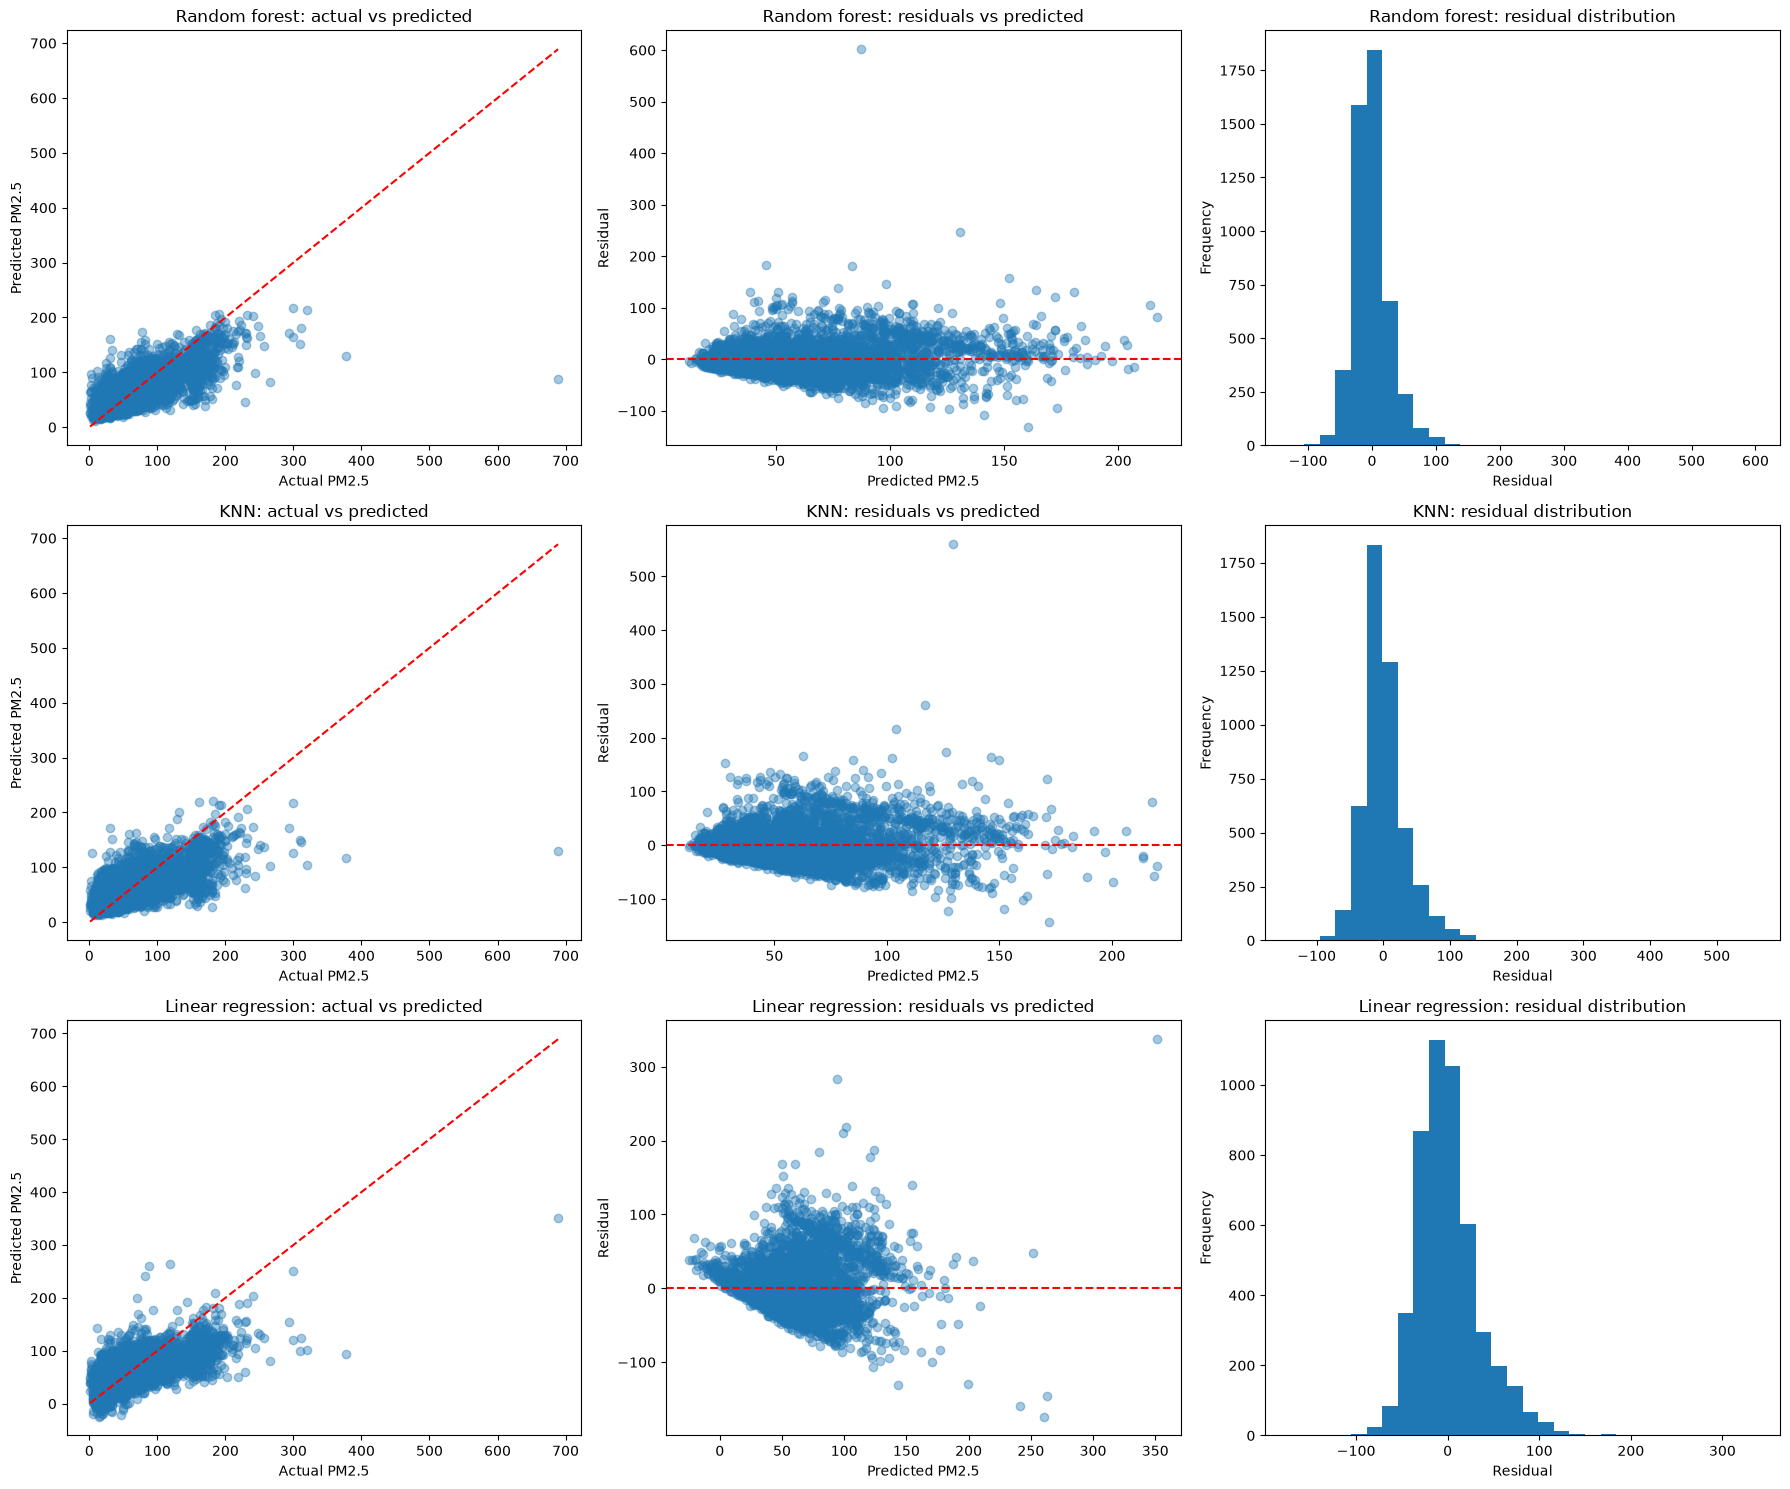

In [80]:
# Residual analysis for the main regression models
residual_model_names = [
    "Random forest",
    "KNN",
    "Linear regression",
]

fig, axes = plt.subplots(
    nrows=len(residual_model_names),
    ncols=3,
    figsize=(18, 5 * len(residual_model_names)),
    squeeze=False,
)

for row, model_name in enumerate(residual_model_names):
    model = fitted_models[model_name]
    validation_predictions = model.predict(x_val)
    residuals = y_val - validation_predictions

    axes[row, 0].scatter(y_val, validation_predictions, alpha=0.4)
    axes[row, 0].plot(
        [y_val.min(), y_val.max()],
        [y_val.min(), y_val.max()],
        "r--",
    )
    axes[row, 0].set_xlabel("Actual PM2.5")
    axes[row, 0].set_ylabel("Predicted PM2.5")
    axes[row, 0].set_title(f"{model_name}: actual vs predicted")

    axes[row, 1].scatter(validation_predictions, residuals, alpha=0.4)
    axes[row, 1].axhline(0, color="red", linestyle="--")
    axes[row, 1].set_xlabel("Predicted PM2.5")
    axes[row, 1].set_ylabel("Residual")
    axes[row, 1].set_title(f"{model_name}: residuals vs predicted")

    axes[row, 2].hist(residuals, bins=30)
    axes[row, 2].set_xlabel("Residual")
    axes[row, 2].set_ylabel("Frequency")
    axes[row, 2].set_title(f"{model_name}: residual distribution")

plt.tight_layout()
plt.show()

In [81]:
# Gradient Boosting

gradient_boosting_model = make_pipeline(
    GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    )
)

gradient_boosting_model.fit(x_train, y_train)
fitted_models["Gradient boosting"] = gradient_boosting_model

gradient_predictions = gradient_boosting_model.predict(x_val)

gradient_results = pd.DataFrame([{
    "model": "Gradient boosting",
    "validation_rmse": np.sqrt(mean_squared_error(y_val, gradient_predictions)),
    "validation_mae": mean_absolute_error(y_val, gradient_predictions),
    "validation_r2": r2_score(y_val, gradient_predictions),
}])

# Compare Gradient Boosting with the existing baseline models.
all_model_results = pd.concat([
    results[["model", "validation_rmse", "validation_mae", "validation_r2"]],
    gradient_results,
], ignore_index=True).sort_values("validation_r2", ascending=False)

print("Gradient Boosting validation metrics:")
display(gradient_results.round(3))

print("Comparison with the baseline models:")
display(all_model_results.round(3))

Gradient Boosting validation metrics:


,model,validation_rmse,validation_mae,validation_r2
0,Gradient boosting,34.215,24.64,0.455


Comparison with the baseline models:


,model,validation_rmse,validation_mae,validation_r2
0,Random forest,29.482,20.491,0.596
1,KNN,33.628,23.566,0.474
3,Gradient boosting,34.215,24.640,0.455
2,Linear regression,35.257,25.961,0.422


In [89]:
# Apply the selected model to the unseen test data
best_model_name = all_model_results.iloc[0]["model"]
best_model = fitted_models[best_model_name]
test_predictions = best_model.predict(X_test)

test_results = pd.DataFrame({
    "Place_ID X Date": test["Place_ID X Date"],
    "target": test_predictions,
})

print(f"Model used for Test.csv predictions: {best_model_name}")
print("X_test shape:", X_test.shape)
display(test_results.head())

Model used for Test.csv predictions: Random forest
X_test shape: (16136, 54)


,Place_ID X Date,target
0,0OS9LVX X 2020-01-02,44.428190
1,0OS9LVX X 2020-01-03,38.407011
2,0OS9LVX X 2020-01-04,32.163006
3,0OS9LVX X 2020-01-05,29.670440
4,0OS9LVX X 2020-01-06,36.752275


In [88]:
# Save predictions as a submission file
submission_path = Path("data/SampleSubmission_KSD.csv")
submission = test_results[["Place_ID X Date", "target"]].copy()
submission.to_csv(
    submission_path,
    index=False,
    float_format="%.6f",
    chunksize=1000,
 )

print(f"Saved predictions to: {submission_path}")
print(f"Submission shape: {submission.shape}")
display(submission.head())

Saved predictions to: data\SampleSubmission_KSD.csv
Submission shape: (16136, 2)


,Place_ID X Date,target
0,0OS9LVX X 2020-01-02,44.428190
1,0OS9LVX X 2020-01-03,38.407011
2,0OS9LVX X 2020-01-04,32.163006
3,0OS9LVX X 2020-01-05,29.670440
4,0OS9LVX X 2020-01-06,36.752275
